# Exploratory data analyses

## Introduction:

##### This notebook is about exploring the **Final dataset**, which was created in the [02_final_data_preperation](../cleaning_part_2/02_final_data_preparation.ipynb) notebook!

The aim of this notebook is to explore the features of the final dataset, observe their distributions, look for outliers and most importantly it will try to understand which would be the best approaches of preprocessing the data, as scaling, encoding, imputation and any other transformations before the modelling!


#### Data exploration:
In this part, I will try to understand a little more about the features, their distributions, value ranges, outliers, cardinality(for categorical), class balances and everything whichb can help us make better modeling later!

Here is what I plan to do: \
Instead of expecting each feature on its own I will group them!With ~200 features, column-by-column EDA would take hours and produce noise. The key insight is that features within the same semantic group share the same statistical behaviour, the same outlier patterns, and the same preprocessing needs. Profiling 12 groups instead of 200 columns will saves a lot of time — **because any feature that deviates from its group's pattern is immediately visible as an exception.**

After the data is explored and each of the features are analyzed, we will have a better look at what we are dealing with, and more over, we will know what would be the best way of transforming the data, dealing with the missing values, scaling and encoding the categorical data!All of these things will be formed as assumptions from here!

##### More specifications:
**Binary flags**: Class balance is the only thing that matters. A flag that is positive 2% of the time is essentially useless as a standalone feature — the model will learn to ignore it. home_cup_final_recent and similar rare-event flags may fall into this category. The output tells you exactly which flags to reconsider or combine.

**Categorical features**: Cardinality will determine the encoding strategy. **referee** (high cardinality, ~50+ referees) needs target encoding, not one-hot. **result_full** (3 values) needs one-hot. h_title/a_title (31 La Liga teams) is medium cardinality — target encoding would be suitable, but we can also drop these features entirely in favour of the already-computed ELO and squad strength features!

**Outlier detection (all numeric groups):** Two methods will be tried — IQR fences (standard) and Modified Z-score (Hampel, using median and MAD). IQR alone misses outliers in skewed distributions. Modified Z-score alone can flag too many points in multimodal distributions. Together they give a robust picture. The output includes exact clip values (clip_lo, clip_hi) ready to use into the preprocessing pipeline.

**Rolling form (G6):** Grouped into sub-groups (goals, shots, xG, possession, H2H) and summarised at sub-group level. This is deliberate — 36 rolling features have nearly identical statistical profiles within each sub-group, so one recommendation covers all of them.

Odds (G7): Gets special attention because the recommendation is to not use raw odds at all. Converting to overround-adjusted implied probabilities will give us values that are naturally in [0,1], sum to 1, and are directly interpretable as model-consistent win probabilities. The final recommendations section will show the exact formula!

### Getting started:

### Loading the required libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from football_betting_analysis.features.constants import FEATURE_GROUPS

from football_betting_analysis.plots.plot_bar import plot_bars
from football_betting_analysis.plots.plot_hist import plot_hists

from football_betting_analysis.features.features_exploration import profile_binary_flags, profile_categorical, profile_group 
from football_betting_analysis.data.team_match_validation import validate_team_matches

### Loading the final dataset

In [2]:
final_df = pd.read_parquet('../../data/processed/processed_final_dataset_v1.parquet')

In [3]:
final_df.shape

(4180, 197)

In [4]:
final_df.columns.tolist()

['season',
 'date',
 'h_title',
 'a_title',
 'home_elo',
 'away_elo',
 'home_form_last_3',
 'home_form_last_5',
 'away_form_last_3',
 'away_form_last_5',
 'result_full',
 'handicap_home',
 'handicap_away',
 'odds_bet365_home',
 'odds_bet365_draw',
 'odds_bet365_away',
 'time',
 'referee',
 'round',
 'game_id',
 'home_club_id',
 'away_club_id',
 'home_club_position',
 'away_club_position',
 'home_club_manager_name',
 'away_club_manager_name',
 'stadium',
 'attendance',
 'home_missing_players_count',
 'home_missing_key_players_count',
 'home_missing_star_players_count',
 'home_missing_importance_sum',
 'home_missing_defenders',
 'home_missing_midfielders',
 'home_missing_forwards',
 'home_starting_goalkeeper_missing',
 'home_missing_captain',
 'home_missing_top1_player',
 'home_missing_top3_player',
 'home_available_strength',
 'home_missing_expected_starter_strength',
 'home_missing_gk_strength',
 'home_missing_def_strength',
 'home_missing_mid_strength',
 'home_missing_fwd_strength',
 

---

### Data validation

#### Duplicates checking:

In [5]:
final_df.duplicated(
    subset=['date', 'h_title', 'a_title']
).sum()

np.int64(0)

#### Validating matches across the seasons

In [6]:
final_df['season'].value_counts()

season
2014/2015    380
2015/2016    380
2016/2017    380
2017/2018    380
2018/2019    380
2019/2020    380
2020/2021    380
2021/2022    380
2022/2023    380
2023/2024    380
2024/2025    380
Name: count, dtype: int64

#### Validating teams games across the seasons

In [7]:
result = validate_team_matches(data=final_df, home_team_title='h_title', away_team_title='a_title')

In [8]:
result

{'2014/2015': 20,
 '2015/2016': 20,
 '2016/2017': 20,
 '2017/2018': 20,
 '2018/2019': 20,
 '2019/2020': 20,
 '2020/2021': 20,
 '2021/2022': 20,
 '2022/2023': 20,
 '2023/2024': 20,
 '2024/2025': 20}

---

### Features exploration

I will separate the features into the following groups:
Groups defined:
- G0 — Identifiers / targets (drop before modelling)
- G1 — Binary / flag features (int8, 0/1)
- G2 — Categorical features
- G3 — Count integer features (non-negative integers)
- G4 — Bounded ratio features ([0, 1] by construction)
- G5 — Signed gap / pressure (can be negative)
- G6 — Rolling form features (last-5 windows)
- G7 — Match odds (heavy right-skew expected)
- G8 — xG and shot quality (moderate right-skew)
- G9 — ELO / strength / importance (potentially wide range)
- G10 — Attendance features
- G11 — Referee / manager features

### In order to explore all of these features I have defined different functions, depending on the feature group which functions analyze the specific groups and returns detail summary of statistics and metrics within the group as also posible recomendation how the group of features should be handled!

#### About the functions:

The functions implement a feature profiling and preprocessing recommendation functionality. They analyze every feature, compute descriptive statistics, detect data quality issues, estimate distribution characteristics, and then recommend preprocessing steps such as scaling, transformations, clipping, or encoding.

### 1.**numeric_profile()**:
This function computes a statistical summary of one numerical feature.

Is expect questions like:
- Is the variable normally distributed?
- Is it skewed?
- Does it contain outliers?
- How many values are missing?
- What are the typical values?


#### **Quartiles**:
Quartiles divide the data into four equal parts.
- Q1 (25th percentile)
- Median (50th percentile)
- Q3 (75th percentile)
- Interquartile Range (IQR)

For large IQR the data is considered spread out. \
For small IQR date is considered concentrated.

#### Tukey Outlier Fences
`lo_fence = q1 - 1.5 * iqr` and `hi_fence = q3 + 1.5 * iqr`
Anything outside these limits is considered an outlier.


#### Count IQR outliers
`((s < lo_fence) | (s > hi_fence)).sum()` - This simply counts how many observations violate the fences.

####: Modified Z-score (Hampel)
Unlike the usual Z-score, this method is robust to outliers.

First compute Median then **Median Absolute Deviation (MAD)**

#### Kurtosis
The Kurtosis measures tail heaviness.

High kurtosis - Many extreme observations. \
Low kurtosis - Flatter distribution.

#### Jarque–Bera Test
A test statistic whic tests whether data looks normally distributed.

The returned p-value tells us: 
- Large p-value (>0.05) - Cannot reject normality.
- Small p-value (<0.05) - Data is probably not normal.

These summarize the distribution while being less sensitive to outliers than the minimum and maximum.

---

### 2.**recommend_scaling()**:
This fuction defines rules based on the summary statistics got from the features group profile functions!
Instead of calculating statistics, it uses the profile to recommend preprocessing.

It decides:
- transformation
- scaling
- clipping
- notes

#### Missing values
if a lot missing, consider dropping the full column, if not median imputation!

#### Binary features 
These features are already standardized. \
Scaling them usually adds no benefit.

#### Bounded variables:
Variables already in [0,1] are already normalized.
- Odds - Very right-skewed.Maybe transform with **log1p**

#### Outlier clipping
Large percentage of outliers - recommend clipping \
This reduces extreme influence.

#### Scaling recommendations
- **StandardScaler** produces mean = 0 and sd = 1 - Works well for approximately normal data.
- **RobustScaler** uses median and IQR instead of mean/std. - Much better when outliers exist.
- **MinMaxScaler** produces values between 0 and 1 - Again, works well with normally distributed data, but not very suitable for outliers

A scaler is recommended based on the the distribution of data(normal, highly skewed), the outliers(more like extreme values) and the range in which the data falls!

---

### 3. **profile_group()**:
This is mainly an orchestration function. \
For every column: numeric_profile() -> recommend_scaling() -> collect the results into a DataFrame and creates one summary row per feature.

---

#### 4. **profile_categorical()**:
This profiles categorical variables.

It computes:
- number of unique values
- most common category
- frequency of most common category
- missing values

Then recommends an encoding.

#### Unique values:
Depending on the unqiue values, it decides wether to use one-hot-encoder(small amount of unqiue values) or target/Frequency Encoding(a lot of unique values)

#### Data imbalance:
The functions uses the most common category with `mode()` \
This tells us which category dominates.If certain category is higly dominating that indicates **imbalance**.

- It will be extremely important to see the balance in the target feature(`result`).If the data is highly unbalanced, this will change a lot of things!
- This matters because many machine learning models become biased toward the majority class when the classes are highly imbalanced.

---

#### 5. **profile_binary_flags()**:
This function specializes in binary variables. \
Instead of descriptive statistics, it evaluates class balance.

The function calculates the positive and negative rate of the values and based on that returns **inbalance*:
- **severe** - `pos_rate < 0.05 or pos_rate > 0.95`
- **high** - `pos_rate < 0.10 or pos_rate > 0.90`
- **moderate** - `pos_rate < 0.20 or pos_rate > 0.80`

I will use these functions in order to make the exploration of the data a little bit more faster and more importanly to understand more about the features, their details as trands, patterns and statistics and eventually decide how the data should be preprocessed before modeling, **because the models themselves won't give us the high results, but the features that we have created, their importance, meaning and preprocessing will surely help us**!

#### Now lets begin:

### Missing values:

In [9]:
df = final_df.copy()

In [10]:
missing_summary = (
    df.isna().sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df) * 100).round(2)
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)

In [11]:
missing_summary[missing_summary.missing_pct > 1]

,missing_count,missing_pct
a_h2h_rolling_goal_diff_5,432,10.33
h_h2h_rolling_elo_diff_5,432,10.33
h_h2h_rolling_xG_diff_5,432,10.33
h_h2h_rolling_goal_diff_5,432,10.33
a_h2h_rolling_elo_diff_5,432,10.33
a_h2h_rolling_xG_diff_5,432,10.33


As we can see there are only three features which contain a little bit more missing values.However, for our dataset size this is not a very big problem!For these features I will use an imputation with median maybe.

And as you can guess the median of these features is around zero:

In [12]:
df.h_h2h_rolling_elo_diff_5.median(), df.h_h2h_rolling_goal_diff_5.median(), df.a_h2h_rolling_xG_diff_5.median()

(np.float32(-0.70383096), np.float32(0.0), np.float32(0.08346976))

Lets actually see the distributions of these features:

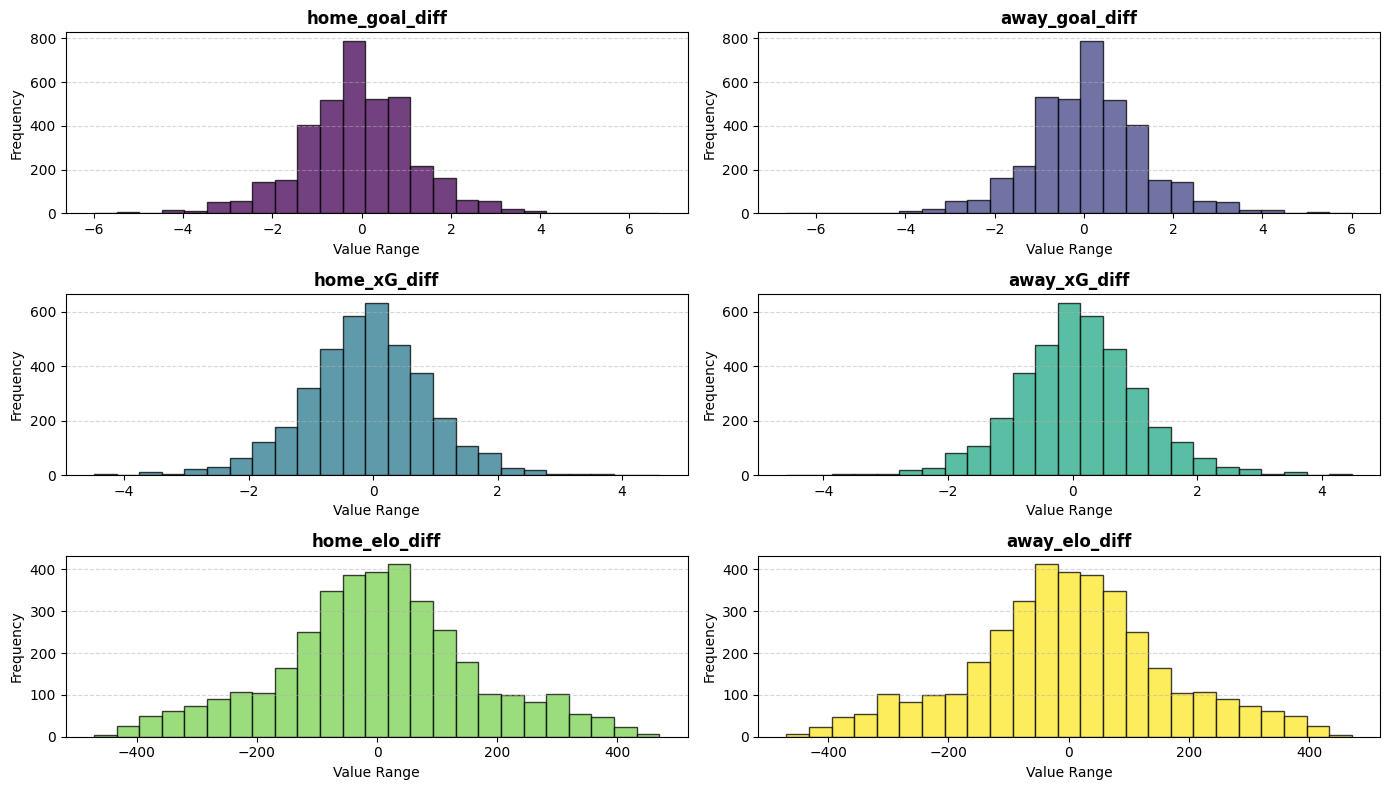

In [13]:
features = {
    'home_goal_diff': df.h_h2h_rolling_goal_diff_5,
    'away_goal_diff': df.a_h2h_rolling_goal_diff_5,
    'home_xG_diff': df.h_h2h_rolling_xG_diff_5,
    'away_xG_diff': df.a_h2h_rolling_xG_diff_5,
    'home_elo_diff': df.h_h2h_rolling_elo_diff_5,
    'away_elo_diff': df.a_h2h_rolling_elo_diff_5
}

plot_hists(features=features, bins=25, ncols=2, nrows=3, xlabel='Value Range', ylabel='Frequency')

All seem to follow a normal distribution with mean at 0.However, for sure there are some extreme values that should be taken into account when scalling the data.For this features I would assume that a `RobustScaler` will be the best fit!

Now I will go over each of the features groups and expect the results from the functions and the recommendations for the features transformations.

First I wil start with the binary features(simple 0/1 values)
### Exploring the Binary features:

In [14]:
g1 = profile_binary_flags(FEATURE_GROUPS["G1_binary_flags"], df)

In [15]:
# All of the features from this group:
g1.feature.unique()

<ArrowStringArray>
['home_starting_goalkeeper_missing', 'away_starting_goalkeeper_missing',
             'home_missing_captain',             'away_missing_captain',
         'home_missing_top1_player',         'away_missing_top1_player',
             'home_title_race_flag',             'away_title_race_flag',
                'home_cl_race_flag',                'away_cl_race_flag',
                'home_el_race_flag',                'away_el_race_flag',
             'home_relegation_flag',             'away_relegation_flag',
       'home_important_match_ahead',       'away_important_match_ahead',
            'home_cup_final_recent',            'away_cup_final_recent',
               'title_direct_clash',                  'cl_direct_clash',
                  'el_direct_clash',          'relegation_direct_clash',
           'relegation_six_pointer',            'direct_position_clash',
                'season_meaningful',         'home_using_new_formation',
         'away_using_new_formati

In [16]:
g1.imbalance.mode()

0    high
Name: imbalance, dtype: str

In [17]:
g1.missing.mean()

np.float64(0.5)

In [18]:
g1.pos_rate.mean(), g1.neg_rate.mean()

(np.float64(0.17469000000000004), np.float64(0.8253099999999999))

As we can see, we have a very big **imbalance** in the this data.This means that if we leave the data in this way, we will add a very big bias to the models.From now I would say that some of the features will be removed.

For example how would features with such severe imbalance help the models:

In [19]:
g1[g1.imbalance == 'severe'].feature

4     home_missing_top1_player
5     away_missing_top1_player
16       home_cup_final_recent
17       away_cup_final_recent
18          title_direct_clash
19             cl_direct_clash
20             el_direct_clash
Name: feature, dtype: str

These features will most probably be removed!

In [20]:
# The features with high imbalance in the data:
g1[g1.imbalance == 'high'].feature

0     home_starting_goalkeeper_missing
1     away_starting_goalkeeper_missing
2                 home_missing_captain
3                 away_missing_captain
6                 home_title_race_flag
7                 away_title_race_flag
8                    home_cl_race_flag
9                    away_cl_race_flag
10                   home_el_race_flag
11                   away_el_race_flag
14          home_important_match_ahead
15          away_important_match_ahead
21             relegation_direct_clash
23               direct_position_clash
29                 high_crowd_pressure
Name: feature, dtype: str

These are a little bit more acceptable, but still can be problematic for the models!

However, lets now observe the categorical features(h_title, a_title, managers names etc):
### Exploring the categorical features:

In [21]:
g2 = profile_categorical(FEATURE_GROUPS["G2_categorical"], df)

In [22]:
g2

,group,feature,n_unique,top_value,top_freq_pct,missing,missing_pct,encoding,notes
0,G2_categorical,season,11,2014/2015,9.1,0,0.0,one-hot,Low cardinality (11) - one-hot encoding recomm...
1,G2_categorical,h_title,31,Athletic Club,5.0,0,0.0,target / ordinal,Medium cardinality (31) - target encoding or f...
2,G2_categorical,a_title,31,Athletic Club,5.0,0,0.0,target / ordinal,Medium cardinality (31) - target encoding or f...
3,G2_categorical,home_formation,27,4-2-3-1,32.8,0,0.0,target / ordinal,Medium cardinality (27) - target encoding or f...
4,G2_categorical,away_formation,28,4-2-3-1,32.2,0,0.0,target / ordinal,Medium cardinality (28) - target encoding or f...
5,G2_categorical,result_full,3,H,45.4,0,0.0,one-hot,Low cardinality (3) - one-hot encoding recomme...
6,G2_categorical,referee,51,Jesús Gil,5.1,0,0.0,target / ordinal,Medium cardinality (51) - target encoding or f...
7,G2_categorical,stadium,42,Abanca Balaídos,5.0,0,0.0,target / ordinal,Medium cardinality (42) - target encoding or f...
8,G2_categorical,home_club_position,20,7,5.4,0,0.0,one-hot,Low cardinality (20) - one-hot encoding recomm...
9,G2_categorical,away_club_position,20,20,5.3,0,0.0,one-hot,Low cardinality (20) - one-hot encoding recomm...


In this data there is not something so interesting except one very important thing: The mode value of this feature: `result_full`!As we can see most of the matches are won by the **Home** team.This is something very important because it shows us that the home venue factor is something very important in footall!

Lets actually see the team venue distribution of the matches: 

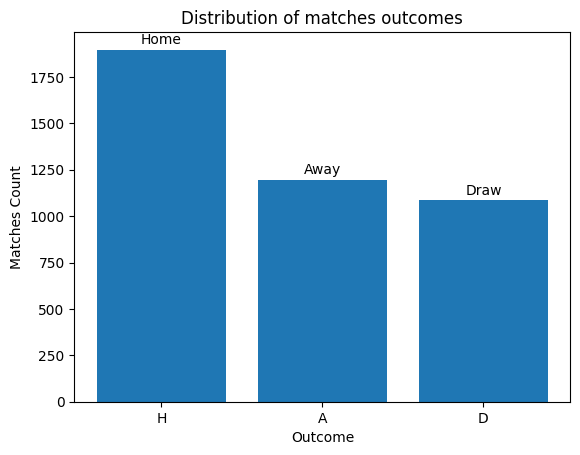

In [23]:
results = final_df.result_full.value_counts()

bar = plt.bar(results.index, results.values)
plt.bar_label(bar, ['Home', 'Away', 'Draw'], padding=2)

plt.xlabel('Outcome')
plt.ylabel('Matches Count')

plt.title('Distribution of matches outcomes')
plt.show()

As we can see there is a strong dominance in the Home wins!This is actally logical and very usual in football.

The thing is that this wil be the target variable that we want to predict and from now I can say that the models will have bias to the **H** class.

Another thing which we should think about is the Draw outcome.Most of the models strugle a lot with this outcome, because it is very rare in footall!By rare I don't mean that it does not appear frequently, but it is something which is more specific and most of the models just cannot capture it!So we should take this into account when creating the models!

ABout the other features:

##### Features suitable for one hot encoding:

In [24]:
g2[g2.encoding == 'one-hot']

,group,feature,n_unique,top_value,top_freq_pct,missing,missing_pct,encoding,notes
0,G2_categorical,season,11,2014/2015,9.1,0,0.0,one-hot,Low cardinality (11) - one-hot encoding recomm...
5,G2_categorical,result_full,3,H,45.4,0,0.0,one-hot,Low cardinality (3) - one-hot encoding recomme...
8,G2_categorical,home_club_position,20,7,5.4,0,0.0,one-hot,Low cardinality (20) - one-hot encoding recomm...
9,G2_categorical,away_club_position,20,20,5.3,0,0.0,one-hot,Low cardinality (20) - one-hot encoding recomm...


From these features I would probably remove the season just because there is nothing intersting it and it will not add any useful information to the models!

The position features can be very usefull!

Now lets see the numerical count features(missing_players_count type featutes):
### Exploring the numerical count-type features:

In [25]:
g3 = profile_group("G3_counts_integers", FEATURE_GROUPS["G3_counts_integers"], df)

C:\Users\Asus\Desktop\Data_Science\Football_Betting_Analysis\Football_Betting_Analysis\src\football_betting_analysis\features\features_exploration.py:33: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk = float(skew(s))
C:\Users\Asus\Desktop\Data_Science\Football_Betting_Analysis\Football_Betting_Analysis\src\football_betting_analysis\features\features_exploration.py:34: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kt = float(kurtosis(s))


In [26]:
g3[[
    "feature", "mean", "median", "std", "min", "max",
    "skewness", "iqr_outliers", "p25", "p75", "mz_outliers", "iqr_outlier_pct", "missing_pct", "transform", "scaler"
]]

,feature,mean,median,std,min,max,skewness,iqr_outliers,p25,p75,mz_outliers,iqr_outlier_pct,missing_pct,transform,scaler
0,home_missing_players_count,2.1127,2.0,1.7264,0.0,11.0,0.873,63,1.0,3.0,30,1.51,0.05,none,minmax
1,away_missing_players_count,2.2033,2.0,1.8200,0.0,16.0,0.984,91,1.0,3.0,44,2.18,0.07,none,minmax
2,home_missing_key_players_count,0.5428,0.0,0.7575,0.0,4.0,1.405,90,0.0,1.0,0,2.15,0.05,sqrt,minmax
3,away_missing_key_players_count,0.5609,0.0,0.7785,0.0,7.0,1.480,95,0.0,1.0,0,2.27,0.07,sqrt,minmax
4,home_missing_star_players_count,0.0969,0.0,0.3094,0.0,2.0,3.129,388,0.0,0.0,0,9.29,0.05,log1p,robust
5,away_missing_star_players_count,0.0917,0.0,0.3008,0.0,2.0,3.219,368,0.0,0.0,0,8.81,0.07,log1p,robust
6,home_missing_defenders,0.7451,1.0,0.8823,0.0,5.0,1.137,172,0.0,1.0,0,4.12,0.05,sqrt,minmax
7,away_missing_defenders,0.7632,1.0,0.9211,0.0,7.0,1.287,199,0.0,1.0,1,4.76,0.07,sqrt,minmax
8,home_missing_midfielders,0.6127,0.0,0.8346,0.0,6.0,1.481,137,0.0,1.0,0,3.28,0.05,sqrt,minmax
9,away_missing_midfielders,0.6371,0.0,0.8624,0.0,6.0,1.544,151,0.0,1.0,0,3.62,0.07,sqrt,minmax


About the outliers.

The function `numeric_profile` defines an outlier in two ways:
- **IQR Method (outliers_iqr):** Uses Rank-based statistics ($Q1$) and ($Q3$). The Interquartile Range (IQR) focuses exclusively on the middle 50% of the data. It builds a constant bounding box (fences) outside of those quartiles.

- **Modified Z-score Method (outliers_mz)**: Uses Deviation from the center. It relies on the Median and the **Median Absolute Deviation (MAD)**. MAD measures the median distance of every single data point from the central median.

As we can see there is a big difference between the two methods, as the **mz_outliers** tends to define an outlier more strictly.We can see that there are a lot of zeros in this columns and this because of the fact that this method fails to find any outlier(even if there is some), if the 50% of the data is all identical.From what I can see in the first and third quartile, the data seems to have a lot of zeros and almost all of the data is identical!And this is why we have also zeros in the **mz_outliers**!

However, the **outliers_iqr** method handles repeated values much better because ($Q1$) and ($Q3$) rarely collapse to the exact same value unless more than 75% of the data is identical.And this is why I have used this method to define the **iqr_outlier_pct**, based on which a scaler is recommended.For a data which have a lot of extreme values, the **RobustScaler** will be a good way to handle them!

Lets see actuall the features which contains a lot of missing values:

In [27]:
g3[g3.iqr_outlier_pct >= 5][[
    "feature", "mean", "median", "std", "min", "max",
    "skewness", "iqr_outliers", "p25", "p75", "mz_outliers", "iqr_outlier_pct", "missing_pct", "transform", "scaler"
]]

,feature,mean,median,std,min,max,skewness,iqr_outliers,p25,p75,mz_outliers,iqr_outlier_pct,missing_pct,transform,scaler
4,home_missing_star_players_count,0.0969,0.0,0.3094,0.0,2.0,3.129,388,0.0,0.0,0,9.29,0.05,log1p,robust
5,away_missing_star_players_count,0.0917,0.0,0.3008,0.0,2.0,3.219,368,0.0,0.0,0,8.81,0.07,log1p,robust
12,home_missing_top3_player,0.0924,0.0,0.2896,0.0,1.0,2.815,386,0.0,0.0,0,9.24,0.05,log1p,robust
13,away_missing_top3_player,0.0874,0.0,0.2824,0.0,1.0,2.922,365,0.0,0.0,0,8.74,0.07,log1p,robust
22,cl_spots,4.0909,4.0,0.2875,4.0,5.0,2.846,380,4.0,4.0,0,9.09,0.00,log1p,robust
23,el_spots,1.9091,2.0,0.2875,1.0,2.0,-2.846,380,2.0,2.0,0,9.09,0.00,reflect_log1p,robust
27,home_manager_matches_in_post,46.8134,25.0,61.4782,0.0,416.0,2.826,325,10.0,59.0,360,7.78,0.00,log1p,robust
28,away_manager_matches_in_post,47.0199,26.0,61.5330,0.0,417.0,2.824,323,10.0,59.0,338,7.73,0.00,log1p,robust


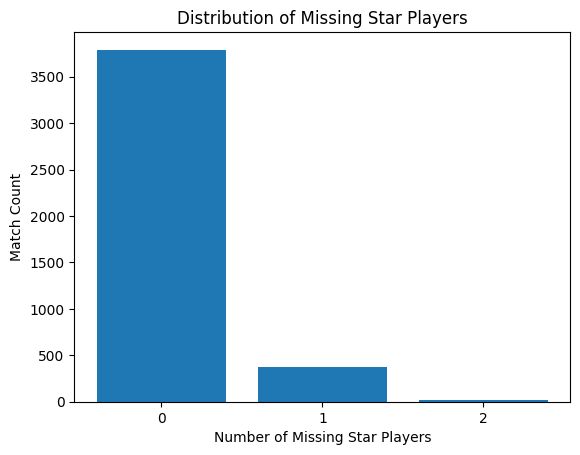

In [28]:
missing_star_players = final_df.home_missing_star_players_count.value_counts()

plt.bar(missing_star_players.index, missing_star_players.values)

plt.xticks(missing_star_players.index)

plt.xlabel('Number of Missing Star Players')
plt.ylabel('Match Count')
plt.title('Distribution of Missing Star Players')

plt.show()

In [29]:
missing_star_players

home_missing_star_players_count
0.0    3790
1.0     371
2.0      17
Name: count, dtype: int64

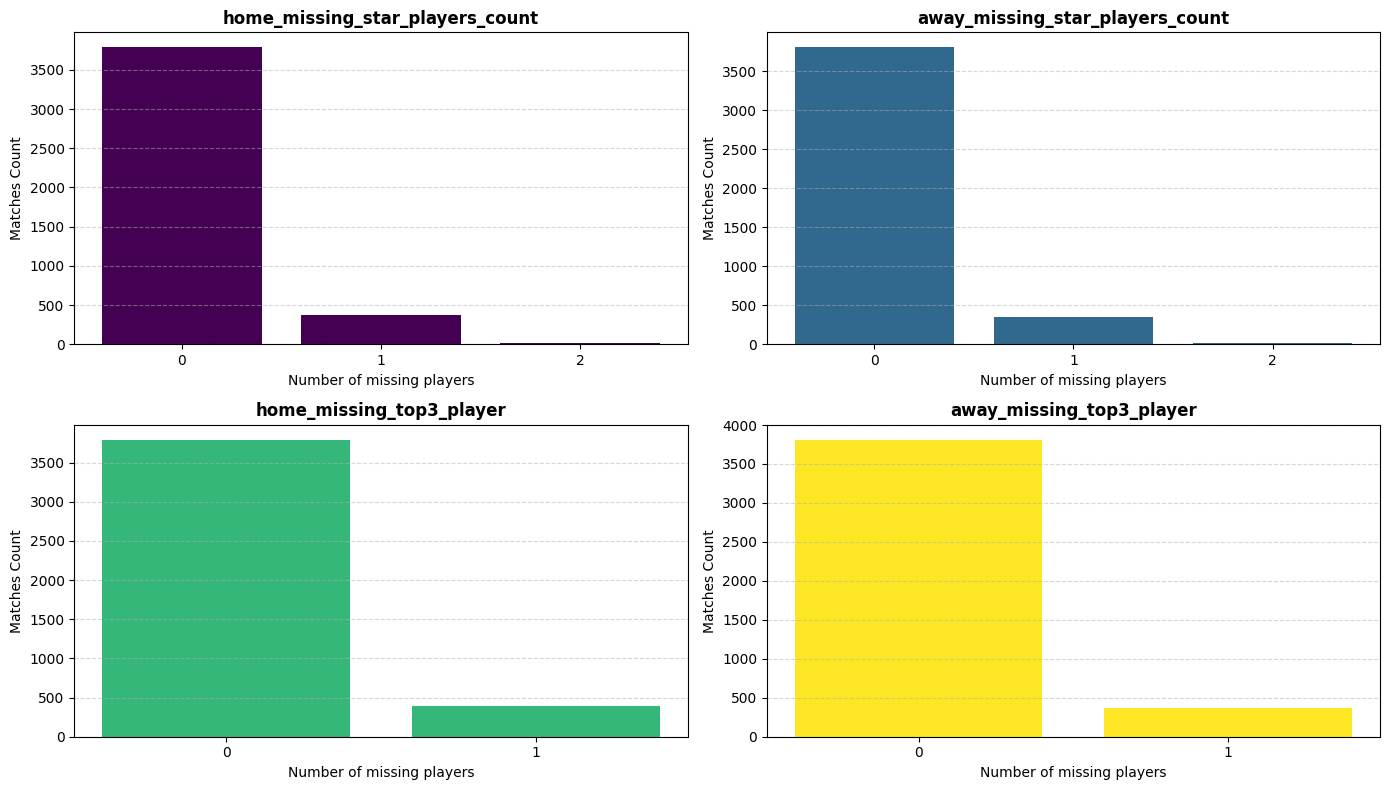

In [30]:
features = {
    'home_missing_star_players_count': final_df.home_missing_star_players_count.value_counts(), 
    'away_missing_star_players_count': final_df.away_missing_star_players_count.value_counts(),
    'home_missing_top3_player': final_df.home_missing_top3_player.value_counts(),        
    'away_missing_top3_player': final_df.away_missing_top3_player.value_counts(),
}

plot_bars(
    features=features, 
    nrows=2, 
    ncols=2, 
    xlabel='Number of missing players', 
    ylabel='Matches Count')

We can see that all of these features have mostly zeros as values and the data is almost identical.Except the fact that they have a lot of extreme values, they also do not provide any meaningful information, because almost all of the data is identical!

I would consider removing these columns!

#### Exploring the bouded ratios features:

In [31]:
g4 = profile_group("G4_bounded_ratios", FEATURE_GROUPS["G4_bounded_ratios"], df)

In [32]:
g4[["feature", "mean", "median", "std", "min", "max",
    "skewness", "iqr_outlier_pct", "missing_pct", "transform"]]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform
0,home_squad_stability,0.9255,0.9387,0.0706,0.5626,1.0000,-0.974,0.86,0.05,none
1,away_squad_stability,0.9225,0.9370,0.0740,0.3713,1.0000,-1.056,0.69,0.07,none
2,home_missing_importance_ratio,0.0737,0.0614,0.0650,0.0000,0.4122,0.965,1.46,0.05,none
3,away_missing_importance_ratio,0.0765,0.0634,0.0675,0.0000,0.5506,0.986,1.34,0.07,none
4,home_title_pressure,0.0350,0.0000,0.1529,-0.0000,1.0000,4.933,8.47,0.00,sqrt
5,away_title_pressure,0.0349,0.0000,0.1529,-0.0000,1.0000,4.998,8.54,0.00,sqrt
6,home_cl_pressure,0.0469,0.0000,0.1727,0.0000,1.0000,4.251,12.13,0.00,sqrt
7,away_cl_pressure,0.0469,0.0000,0.1721,0.0000,1.0000,4.204,11.67,0.00,sqrt
8,home_el_pressure,0.0372,0.0000,0.1556,0.0000,1.0000,4.822,9.07,0.00,sqrt
9,away_el_pressure,0.0369,0.0000,0.1541,0.0000,1.0000,4.777,8.61,0.00,sqrt


For this group most of the features seems to be fine, but there are some features which grab my attention: the **pressure** features:

Lets see them:

In [33]:
g4[
    g4.skewness > 2
][["feature", "mean", "median", "std", "min", "max",
    "skewness", "iqr_outlier_pct", "missing_pct", "transform"]]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform
4,home_title_pressure,0.0350,0.0,0.1529,-0.0,1.0,4.933,8.47,0.0,sqrt
5,away_title_pressure,0.0349,0.0,0.1529,-0.0,1.0,4.998,8.54,0.0,sqrt
6,home_cl_pressure,0.0469,0.0,0.1727,0.0,1.0,4.251,12.13,0.0,sqrt
7,away_cl_pressure,0.0469,0.0,0.1721,0.0,1.0,4.204,11.67,0.0,sqrt
8,home_el_pressure,0.0372,0.0,0.1556,0.0,1.0,4.822,9.07,0.0,sqrt
9,away_el_pressure,0.0369,0.0,0.1541,0.0,1.0,4.777,8.61,0.0,sqrt
10,home_relegation_pressure,0.1118,0.0,0.2549,-0.0,1.0,2.414,20.89,0.0,sqrt
11,away_relegation_pressure,0.1078,0.0,0.2502,-0.0,1.0,2.472,21.05,0.0,sqrt


As we can see these features have asymmetrical right-tailed distributions with a a lot of extreme values.On top of that the data is highly **zero-inflated**!

Lets see:

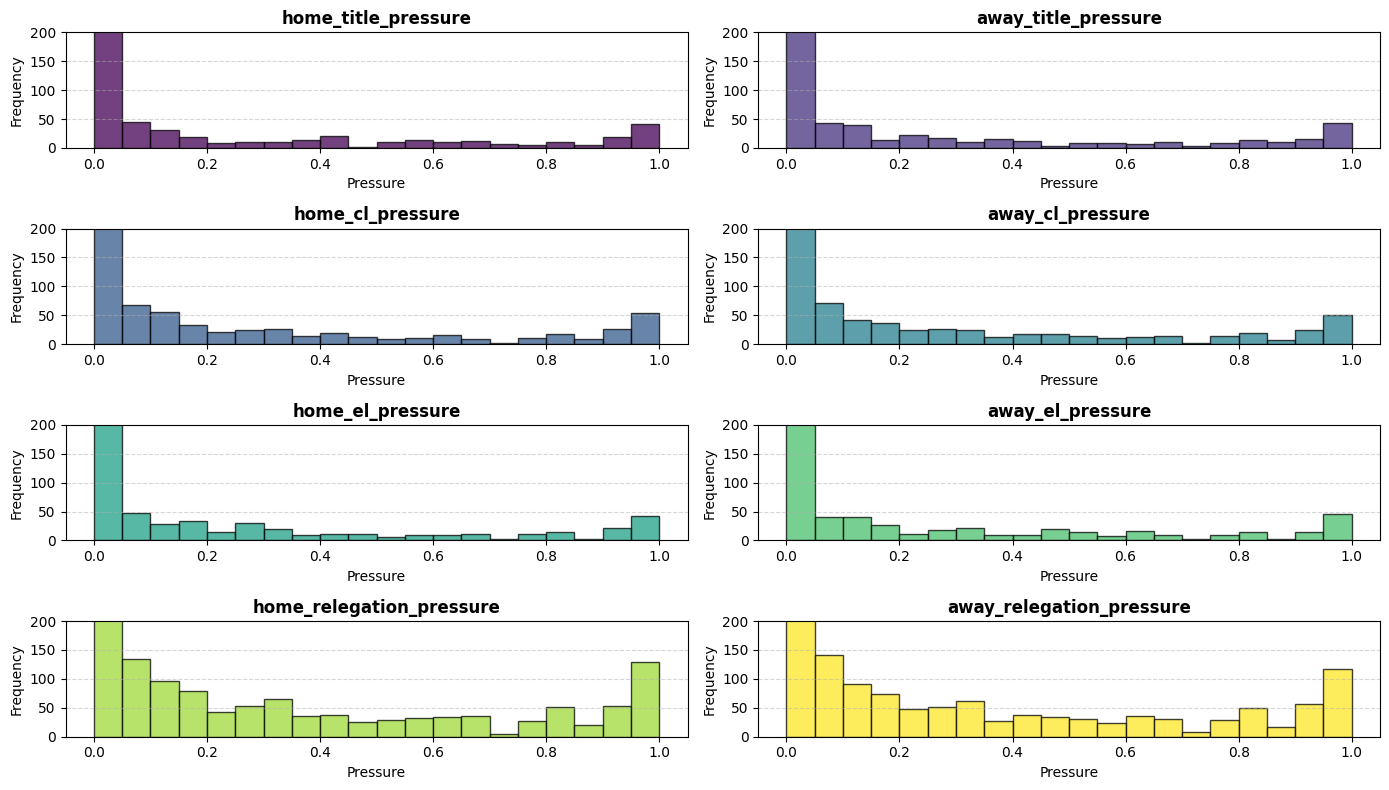

In [34]:
features = {
    'home_title_pressure': final_df.home_title_pressure,            
    'away_title_pressure': final_df.away_title_pressure,
    'home_cl_pressure': final_df.home_cl_pressure,
    'away_cl_pressure': final_df.away_cl_pressure,
    'home_el_pressure': final_df.home_el_pressure,
    'away_el_pressure': final_df.away_el_pressure,
    'home_relegation_pressure': final_df.home_relegation_pressure, 
    'away_relegation_pressure': final_df.away_relegation_pressure   
}

plot_hists(features=features, bins=20, nrows=4, ncols=2, xlabel='Pressure', ylabel='Frequency', ylim=[0, 200])

As we can see the features are very zero-infated with very long right tails!

So what would be the best way to preprocess these fetaures.I would say that the **RobustScaler and PowerTransformer** combined will give the best result, based on the data we have:

**1.Power Transformation (Yeo-Johnson)**:**Power Transfoemer** with the Yeo-Johnson method handles zero-inflated right-tailed data natively.It stabilizes variance and reduces skewness, making the distribution much closer to a normal shape.

**2.Robust Scaling:** After the power transformation, we can apply the RobustScaler. It subtracts the median and divides by the **Interquartile Range**. Because it relies on percentiles rather than the mean and standard deviation, extreme values no longer distort your scaling!

I think that this would be the best way to handle this data!

Now lets see the zero-inflated and also the ones which are near 1:

In [35]:
floor_features = g4[g4["p75"] < 0.1]["feature"].tolist()
ceil_features = g4[g4["p25"] > 0.9]["feature"].tolist()

In [36]:
floor_features

['home_title_pressure',
 'away_title_pressure',
 'home_cl_pressure',
 'away_cl_pressure',
 'home_el_pressure',
 'away_el_pressure',
 'home_relegation_pressure',
 'away_relegation_pressure']

These are expected.We already saw them!

In [37]:
ceil_features

['home_form_last_3',
 'home_form_last_5',
 'away_form_last_3',
 'away_form_last_5']

These form features are actually very important because they present the team's form in the last 3 to 5 matches.And as we can see from their max values:

In [38]:
g4[g4.feature.str.contains('form_last')][['min', 'max']]

,min,max
14,0.0,9.0
15,0.0,15.0
16,0.0,9.0
17,0.0,15.0


A team can have won maximum 15 points from the last 5 mathces(one match = 3 points) and 9 points from the last 3 matches.

These features will be used for for sure and I think that a StandardScaler would be good for them!

### Exploring the Signed gap features:

In [39]:
g5 = profile_group("G5_signed_gaps", FEATURE_GROUPS["G5_signed_gaps"], df)

In [40]:
g5_feature_cols = ["feature", "mean", "median", "std", "min", "max",
                    "skewness", "iqr_outlier_pct", "missing_pct", "transform", "scaler", "is_normal"]

In [41]:
g5[
    g5_feature_cols
]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform,scaler,is_normal
0,home_pts_behind_1st,19.9864,17.00,15.4079,0.00,77.0000,0.615,0.29,0.0,none,minmax,False
1,away_pts_behind_1st,19.7734,17.00,15.3194,0.00,77.0000,0.606,0.29,0.0,none,minmax,False
2,home_pts_to_cl,9.5175,8.00,12.0629,-28.00,55.0000,0.486,1.41,0.0,none,standard,False
3,away_pts_to_cl,9.3045,7.00,11.9980,-45.00,56.0000,0.462,1.32,0.0,none,standard,False
4,home_pts_to_el,4.8165,4.00,10.8119,-35.00,43.0000,-0.169,5.84,0.0,none,robust,False
5,away_pts_to_el,4.6036,4.00,10.7394,-52.00,43.0000,-0.210,5.91,0.0,none,robust,False
6,home_pts_to_conf,2.8644,3.00,10.7071,-48.00,43.0000,-0.491,7.63,0.0,none,robust,False
7,away_pts_to_conf,2.6514,3.00,10.5877,-53.00,42.0000,-0.486,7.54,0.0,none,robust,False
8,home_pts_above_relegation,9.5734,6.00,11.6717,-18.00,61.0000,1.432,5.55,0.0,none,robust,False
9,away_pts_above_relegation,9.7864,6.00,11.6338,-21.00,74.0000,1.424,6.10,0.0,none,robust,False


Features for **StandardScaling**:

In [42]:
g5[g5.scaler == 'standard'][g5_feature_cols]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform,scaler,is_normal
2,home_pts_to_cl,9.5175,8.00,12.0629,-28.00,55.0000,0.486,1.41,0.0,none,standard,False
3,away_pts_to_cl,9.3045,7.00,11.9980,-45.00,56.0000,0.462,1.32,0.0,none,standard,False
14,elo_rating_diff,0.1046,-0.45,164.7247,-495.09,470.9801,-0.015,2.06,0.0,none,standard,True


For data which is with normal(approximately) distribution and have a lot of negative values, I would immideatly go with the Standard Scaler, because he expects a normal distribution and scales the data in range [0, 1].

The MinMax Scaler is more for a data that is not normally distributed or when your the model architecture explicitly requires a strictly bounded range!

However, for these three columns I can use both!

Features for **MinMaxScaler**:

In [43]:
g5[g5.scaler == 'minmax'][g5_feature_cols]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform,scaler,is_normal
0,home_pts_behind_1st,19.9864,17.0,15.4079,0.0,77.0,0.615,0.29,0.0,none,minmax,False
1,away_pts_behind_1st,19.7734,17.0,15.3194,0.0,77.0,0.606,0.29,0.0,none,minmax,False
10,home_cum_points,25.1596,23.0,18.2169,0.0,94.0,0.789,1.22,0.0,none,minmax,False
11,away_cum_points,25.3725,23.0,18.2186,0.0,93.0,0.783,1.72,0.0,none,minmax,False
15,position_gap,7.2909,6.0,4.6758,1.0,19.0,0.516,0.00,0.0,none,minmax,False
19,home_days_until_next_nonleague,54.6550,54.5,41.4647,2.0,99.0,-0.045,0.00,0.0,none,minmax,False
20,away_days_until_next_nonleague,54.5756,52.5,41.4325,3.0,99.0,-0.036,0.00,0.0,none,minmax,False


These seems like to be perfect for a MinMaxScaler because they do not follow normal distribution and also contain a lot of extreme values(which is normal for these features specifically) - This means that the MinMaxScaler would be perfect for these features because it will scale them into the range **[0, 1]**!

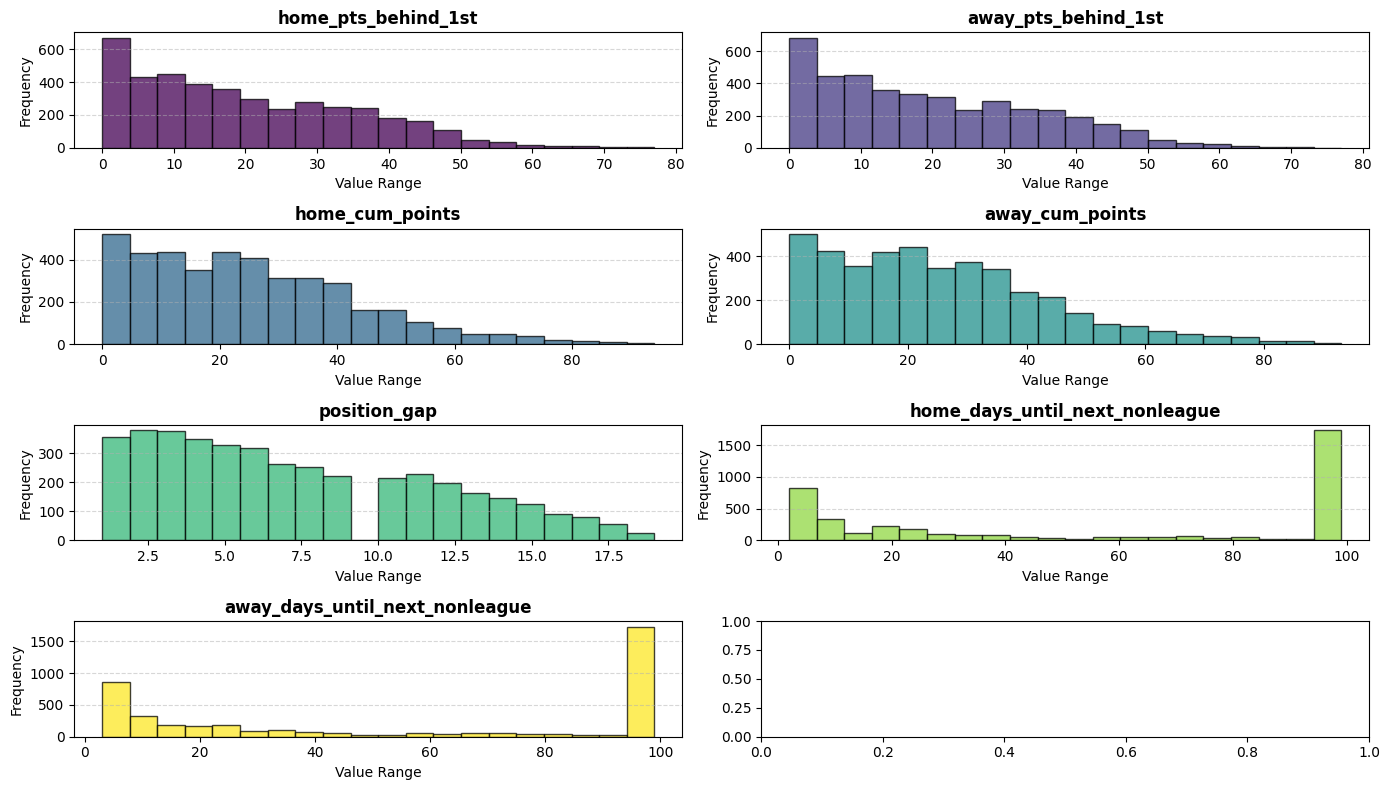

In [44]:
features = {
    'home_pts_behind_1st': final_df.home_pts_behind_1st,
    'away_pts_behind_1st': final_df.away_pts_behind_1st,
    'home_cum_points': final_df.home_cum_points,
    'away_cum_points': final_df.away_cum_points,
    'position_gap': final_df.position_gap, 
    'home_days_until_next_nonleague': final_df.home_days_until_next_nonleague,
    'away_days_until_next_nonleague': final_df.away_days_until_next_nonleague
}

plot_hists(features=features, bins=20, nrows=4, ncols=2, xlabel="Value Range", ylabel='Frequency')

The most interesting seem to be the **days_until_next_nonleague** features.I would say that a simple MinMax scalling won't be enough!

Features for **RobustScaler**:

In [45]:
g5[g5.scaler == 'robust'][g5_feature_cols]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform,scaler,is_normal
4,home_pts_to_el,4.8165,4.0,10.8119,-35.0,43.0,-0.169,5.84,0.0,none,robust,False
5,away_pts_to_el,4.6036,4.0,10.7394,-52.0,43.0,-0.210,5.91,0.0,none,robust,False
6,home_pts_to_conf,2.8644,3.0,10.7071,-48.0,43.0,-0.491,7.63,0.0,none,robust,False
7,away_pts_to_conf,2.6514,3.0,10.5877,-53.0,42.0,-0.486,7.54,0.0,none,robust,False
8,home_pts_above_relegation,9.5734,6.0,11.6717,-18.0,61.0,1.432,5.55,0.0,none,robust,False
9,away_pts_above_relegation,9.7864,6.0,11.6338,-21.0,74.0,1.424,6.10,0.0,none,robust,False
12,home_cum_gd,-0.1246,-1.0,15.6710,-60.0,89.0,1.060,9.40,0.0,none,robust,False
13,away_cum_gd,0.1734,-1.0,15.5962,-61.0,88.0,1.068,9.28,0.0,none,robust,False
16,points_gap_between_teams,10.2531,7.0,10.3759,0.0,66.0,1.603,5.89,0.0,sqrt,robust,False
17,home_days_until_next_match,8.6266,6.0,13.8311,2.0,99.0,5.481,6.91,0.0,log1p,robust,False


For these feature a RobustScaler might be enough, might not.

### Exploring the rolling form features:

In [46]:
g6 = profile_group("G6_rolling_form", FEATURE_GROUPS["G6_rolling_form"], df)

In [47]:
# Deviding the features by type, to create more focused summaries for each of the groups:
def subgroup(col):
        if "goal_diff" in col: return "goal_diff"
        if "goal" in col: return "goals"
        if "shot_conv" in col: return "shot_conversion"
        if "sot" in col: return "shots_on_target"
        if "shot" in col: return "shots"
        if "xG" in col or "xGA" in col: return "xG"
        if "poss" in col: return "possession"
        if "h2h" in col: return "h2h"
        if "chance" in col: return "big_chances"
        return "other"

In [48]:
g6["subgroup"] = g6["feature"].apply(subgroup)
    
summary = g6.groupby("subgroup").agg(
    n_features=("feature", "count"),
    mean_skewness=("skewness", "mean"),
    mean_outlier_pct=("iqr_outlier_pct", "mean"),
    mean_std=("std", "mean"),
    min=("min", "min"),
    max=("max", "max"),
    recommended_transform=("transform", lambda x: x.mode()[0] if len(x) > 0 else "none"),
).round(3)

In [49]:
summary

,n_features,mean_skewness,mean_outlier_pct,mean_std,min,max,recommended_transform
subgroup,,,,,,,
big_chances,2,1.086,2.535,0.732,0.000,6.000,sqrt
goal_diff,4,0.200,2.343,1.130,-6.667,6.667,none
goals,4,0.805,2.555,0.625,0.000,5.000,none
h2h,2,0.000,2.530,164.712,-470.980,470.980,none
possession,6,0.118,0.747,10.015,-48.800,74.400,none
shot_conversion,2,0.720,1.740,0.054,0.000,0.500,none
shots,6,0.558,1.687,1.779,0.016,27.000,none
shots_on_target,4,0.606,2.027,1.258,0.000,10.600,none
xG,10,0.744,2.362,0.521,-4.595,4.595,none


In [50]:
feature_cols = ["feature", "mean", "median", "std", "min", "max",
                    "skewness", "iqr_outlier_pct", "missing_pct", "transform", "scaler", "is_normal"]

In [51]:
g6[feature_cols]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform,scaler,is_normal
0,h_rolling_goals_5,1.2913,1.2000,0.6543,0.0000,5.0000,1.069,2.47,0.36,sqrt,minmax,False
1,h_rolling_goals_against_5,1.3283,1.2000,0.5953,0.0000,4.0000,0.546,3.84,0.36,none,minmax,False
2,h_rolling_shots_5,11.6471,11.4000,2.6825,2.0000,23.6000,0.699,2.35,0.36,none,minmax,False
3,h_rolling_shots_against_5,11.9568,11.8000,2.6382,5.0000,27.0000,0.397,1.15,0.36,none,minmax,False
4,h_rolling_sot_5,4.0770,3.8000,1.3281,0.0000,10.6000,0.848,2.71,0.36,none,minmax,False
5,h_rolling_sot_against_5,4.1873,4.2000,1.1885,0.0000,9.2000,0.364,1.25,0.36,none,minmax,False
6,h_rolling_xG_5,1.3230,1.2258,0.5104,0.0309,3.9589,1.123,3.17,0.36,sqrt,minmax,False
7,h_rolling_xGA_5,1.3634,1.3287,0.4439,0.3089,4.1785,0.562,1.06,0.36,none,minmax,False
8,h_rolling_goal_diff_5,-0.0371,0.0000,0.9596,-3.6000,4.8000,0.394,1.58,0.36,none,standard,False
9,h_rolling_poss_5,49.8525,49.0000,7.5049,27.8000,74.2000,0.381,0.67,0.36,none,minmax,False


For these features either Standard or MinMaxScaler will do a good job, and of course for the normally distrinuted data a Standard Scaler will be the better choice!

Something which grab my attention are the Head-to-Head rolling fetaures.Lets see them:

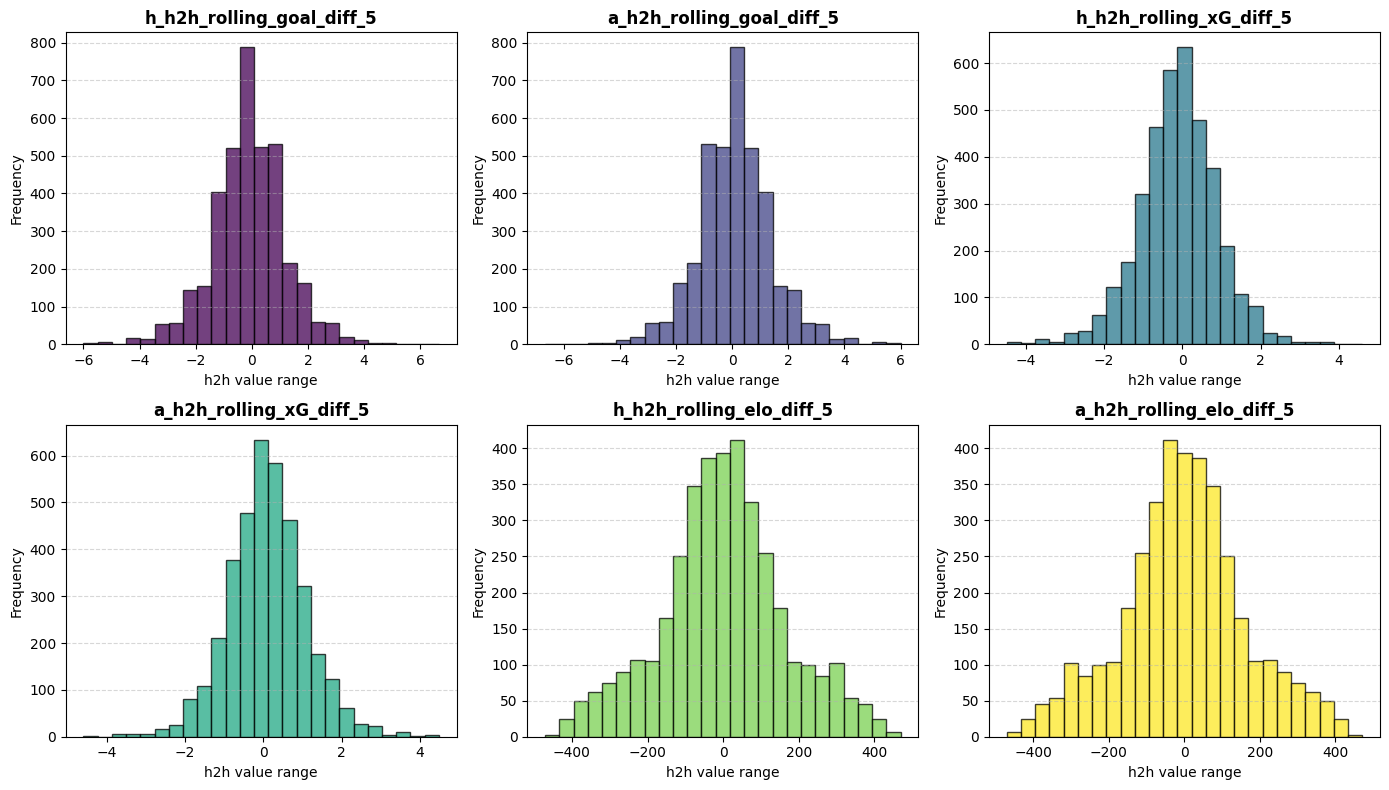

In [52]:
features = {
    'h_h2h_rolling_goal_diff_5': final_df.h_h2h_rolling_goal_diff_5,
    'a_h2h_rolling_goal_diff_5': final_df.a_h2h_rolling_goal_diff_5,
    'h_h2h_rolling_xG_diff_5': final_df.h_h2h_rolling_xG_diff_5,
    'a_h2h_rolling_xG_diff_5': final_df.a_h2h_rolling_xG_diff_5,
    'h_h2h_rolling_elo_diff_5': final_df.h_h2h_rolling_elo_diff_5,
    'a_h2h_rolling_elo_diff_5': final_df.a_h2h_rolling_elo_diff_5
}

plot_hists(
    features=features, 
    bins=25, 
    nrows=2, 
    ncols=3, 
    xlabel='h2h value range', 
    ylabel='Frequency')

These features follow approximately normal distribution, and for this reason I would say that a Standard Scaler will be better than a MinMaxScaler!I would not consider using RobustScaler or PowerTransformer, becase all of the rolling features seems to not have asymmetrical distributions with very long tailes and also from what I can see there are not any visiable extreme values that would make us use the RobustScaler!

### Exploring strength features:

In [53]:
g8 = profile_group("G8_strength", FEATURE_GROUPS["G8_strength"], df)

In [54]:
g8[
    feature_cols
]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform,scaler,is_normal
0,home_elo,1728.0084,1698.6951,115.9195,1482.1801,2100.6799,1.082,5.38,0.00,sqrt,robust,False
1,away_elo,1727.9038,1699.3700,116.1656,1482.1801,2100.6799,1.078,5.17,0.00,sqrt,robust,False
2,home_available_strength,1.4096,1.4062,0.2048,0.0000,3.0219,-0.178,2.42,0.05,none,minmax,False
3,away_available_strength,1.4102,1.4047,0.2038,0.0000,2.9910,-0.231,2.54,0.07,none,minmax,False
4,home_missing_importance_sum,0.1150,0.0939,0.1053,0.0000,0.7228,1.168,1.80,0.05,sqrt,minmax,False
5,away_missing_importance_sum,0.1202,0.0962,0.1109,0.0000,1.0211,1.259,1.82,0.07,sqrt,minmax,False
6,home_missing_expected_starter_strength,0.0980,0.0773,0.0962,0.0000,0.6818,1.177,1.32,0.05,sqrt,minmax,False
7,away_missing_expected_starter_strength,0.1024,0.0798,0.1019,0.0000,0.9629,1.311,1.27,0.07,sqrt,minmax,False
8,home_missing_gk_strength,0.0102,0.0000,0.0287,0.0000,0.2067,2.888,12.61,0.05,log1p,robust,False
9,away_missing_gk_strength,0.0102,0.0000,0.0286,0.0000,0.2086,2.828,12.69,0.07,log1p,robust,False


As we can see these features have a both: very asymetrical distributions and also a lot of extreme values.This is the perfect case to use the combination between a **PowerTransoformer**, which will shrink the very long tails and put the data into a more smaller range and the **RobustScaler**, which will remove the big impact from the extreme values!

### Exploring the Referee/Manager features:

In [55]:
g10 = profile_group("G10_referee_manager", FEATURE_GROUPS["G10_referee_manager"], df)

In [56]:
g10[
    feature_cols
]

,feature,mean,median,std,min,max,skewness,iqr_outlier_pct,missing_pct,transform,scaler,is_normal
0,referee_home_bias,0.0071,0.0000,0.0592,-0.2538,0.2489,0.235,8.47,0.0,none,robust,False
1,referee_foul_rate,0.8436,1.0047,0.3852,0.0000,1.3354,-1.670,17.89,0.0,none,robust,False
2,referee_card_rate,0.8507,0.9883,0.4000,0.0000,1.4839,-1.468,17.01,0.0,none,robust,False
3,home_manager_matches_in_post,46.8134,25.0000,61.4782,0.0000,416.0000,2.826,7.78,0.0,log1p,robust,False
4,away_manager_matches_in_post,47.0199,26.0000,61.5330,0.0000,417.0000,2.824,7.73,0.0,log1p,robust,False
5,home_manager_win_rate,0.3867,0.3636,0.1927,0.0000,1.0000,0.351,1.56,0.0,none,minmax,False
6,away_manager_win_rate,0.3951,0.3707,0.1948,0.0000,1.0000,0.435,2.11,0.0,none,minmax,False


Here we also have asymetrical data!For the **referee_home_bias, referee_foul_rate, referee_card_rate, home_manager_matches_in_post and away_manager_matches_in_post** a Robust Scaler will be good , plus a PowerTransformer for the highly skewed features.

And for the **home_manager_win_rate and away_manager_win_rate**, there is no need for scalling at all, because they are already in range [0, 1], don't have asymetrical distributions and extreme values - No need of scalling this data!

---

## Feature correlation analyses
Now lets have a look at the relations between the features and see if there are any highly correlated features!

In [57]:
numeric_df = df.select_dtypes(include=[np.number])
 
try:
    corr_matrix = numeric_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
    )
    high_corr = high_corr[high_corr["correlation"] > 0.90].sort_values("correlation", ascending=False)
    if len(high_corr) > 0:
        print(f"{len(high_corr)} pairs with |r| > 0.90 found.")
    else:
        print("No pairs with |r| > 0.90 found")
except MemoryError:
    print("Correlation matrix too large")

57 pairs with |r| > 0.90 found.


In [58]:
high_corr.head(30)

,feature_1,feature_2,correlation
2639,home_club_position,home_league_position,1.000000
2851,away_club_position,away_league_position,1.000000
3124,attendance,attendance_num,1.000000
27568,h_h2h_rolling_goal_diff_5,a_h2h_rolling_goal_diff_5,1.000000
27753,h_h2h_rolling_xG_diff_5,a_h2h_rolling_xG_diff_5,1.000000
27938,h_h2h_rolling_elo_diff_5,a_h2h_rolling_elo_diff_5,1.000000
31081,away_formation_changes_5,away_formation_consistency,1.000000
22386,cl_spots,el_spots,1.000000
30526,home_formation_changes_5,home_formation_consistency,1.000000
27011,a_rolling_poss_diff_5,a_rolling_poss_5,0.999957


There are a iot lot of highly correlated features.This will not be good for the models, especially for the Linear ones, because these correlated features will inflate the model complexity, increase the risk of overfitting, and drastically destabilize models that rely on evaluating individual feature importance.

How to handle these features:
- I can simply remove one of the features from the pairs and leave the one which is more interpretable or has a higher correlation with the target variable!This is not so reliable, but it is an option!
- Of course, I can apply some dimensionality reduction technique such as **PCA** or **Kernel PCA** for non-linear data.For sure, I would consider using some of these techniques when modeling
- Another useful approach is to apply some regularization to the data.For example, if using `LogisticRegression`, I can apply **Ridge Regression (L2)** to shrink the impact of correlated features without dropping them, or use **Lasso Regression (L1)**, which automatically shrinks the coefficients of redundant features to zero, acting as an automatic feature selector.

There are a lot of ways to handle these highly correlated features.All of them could be tested!

---

This is everything from this notebook.We have explored all of the features and eventually we have made some important assumptions on that what the right preprocessing of these features would be.The most important thing that we should take into account when modelling:
- Asymetrical, non-normal distributions
- Extreme values(outliers)
- High correlations'
- Data ranges
- Missing values
- **CLass imbalance** - very important

I would say that the we have made one solid exploration and we are ready for the modelling!